# Setup

## Installing additional libraries

In [1]:
pip install torch diffusers transformers accelerate

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


## Importing needed modules

In [2]:
import matplotlib.pyplot as plt
import torch
from diffusers import DDPMPipeline
from torchvision.utils import save_image

from plot import visualize_diffusion_manual, plot_pictures

# Model loading
We load a pre-trained diffusion model from [Hugging Face](https://huggingface.co).

The model is called DDPM (denoising diffusion probabilistic model) and was trained on MNIST.

In [3]:
LOAD_FROM_WEB = False
SAVE_TO_LOCAL = False
LOAD_FROM_LOCAL = True

device = "cpu"
local_path = "./ddpm_model"

In [4]:
if LOAD_FROM_WEB:
    model_id = "1aurent/ddpm-mnist"
    pipeline = DDPMPipeline.from_pretrained(model_id)

    pipeline.to(device)

if SAVE_TO_LOCAL:
    pipeline.save_pretrained(local_path)

if LOAD_FROM_LOCAL:
    pipeline = DDPMPipeline.from_pretrained(local_path)
    pipeline.to(device)

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

## Parameters
We check how many parameters the model includes:

In [5]:
all_params = 0
for component in [
    pipeline.unet,
    getattr(pipeline, "vae", None),
    getattr(pipeline, "text_encoder", None),
]:
    if component:
        all_params += sum(p.numel() for p in component.parameters())

print(f"Total Parameters: {all_params:,}")

Total Parameters: 1,065,153


# Running the Diffusion

### Creating your own images
1. Set `DIFFUSION_STEPS` to the amount of denoising steps you want to have.
2. Set `L_SNAPSHOTS` to the amount of intermediate pictures you want to display
3. Run the below two code cells each time you want to generate a new picture

In [6]:
DIFFUSION_STEPS = 150  # amount of denoising steps we want to make
L_SNAPSHOTS = 10  # amount of pictures we want to display

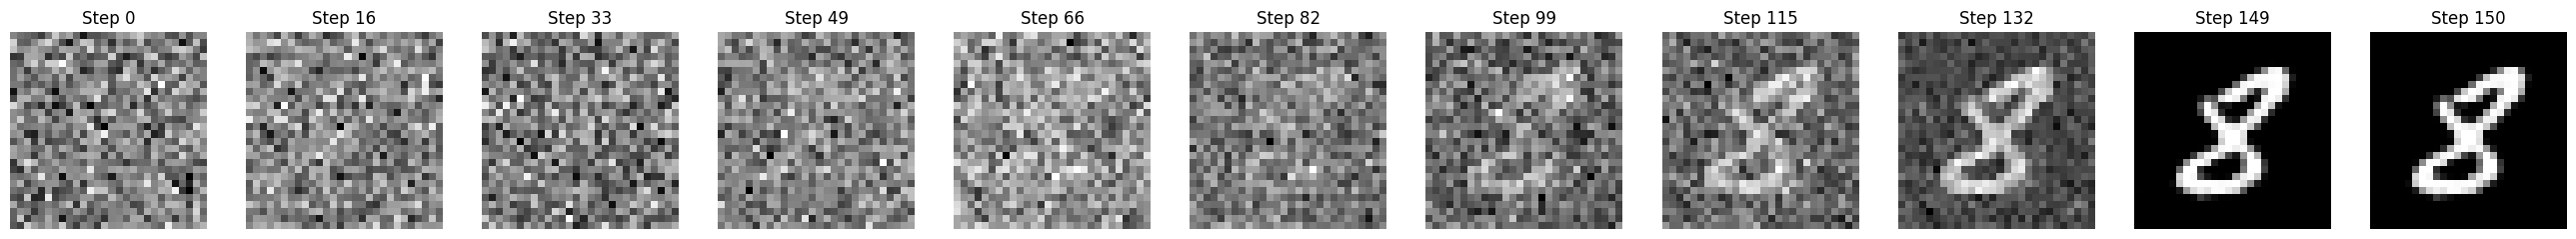

In [7]:
intermediates, noise_preds, noise_scales = visualize_diffusion_manual(
    pipeline, k_steps=DIFFUSION_STEPS, l_snapshots=L_SNAPSHOTS
)

intermediates = torch.cat(intermediates)
noise_preds = torch.cat(noise_preds)
noise_scales = torch.tensor(noise_scales).reshape(-1, 1, 1, 1)

## Visualising the obtained images from the diffusion process

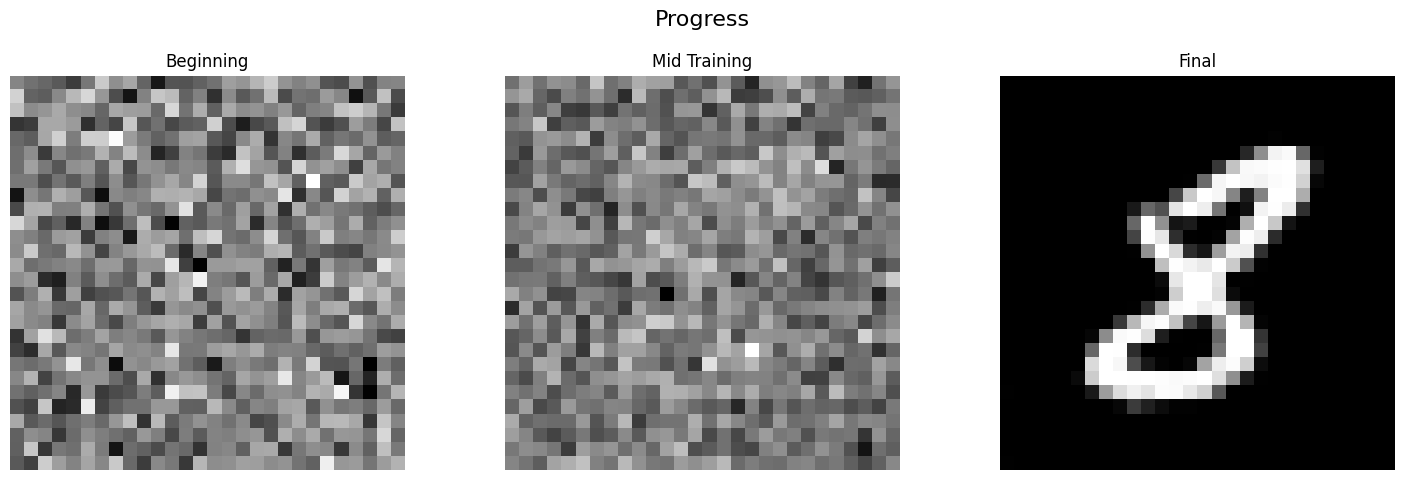

In [8]:
plot_pictures(
    intermediates,
    ["Beginning", "Mid Training", "Final"],
    super_title="Progress",
    same_scale=False,
)

## Visualising the estimated noise from the network

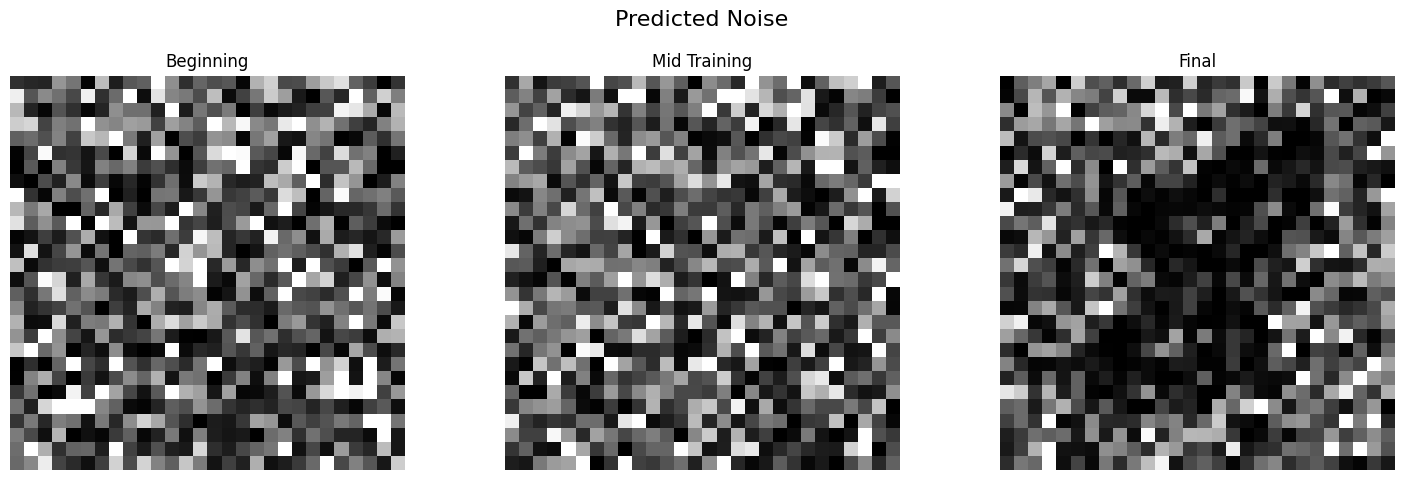

In [9]:
pure_noise = torch.abs(noise_preds)

plot_pictures(
    pure_noise,
    ["Beginning", "Mid Training", "Final"],
    super_title="Predicted Noise",
    same_scale=True,
)

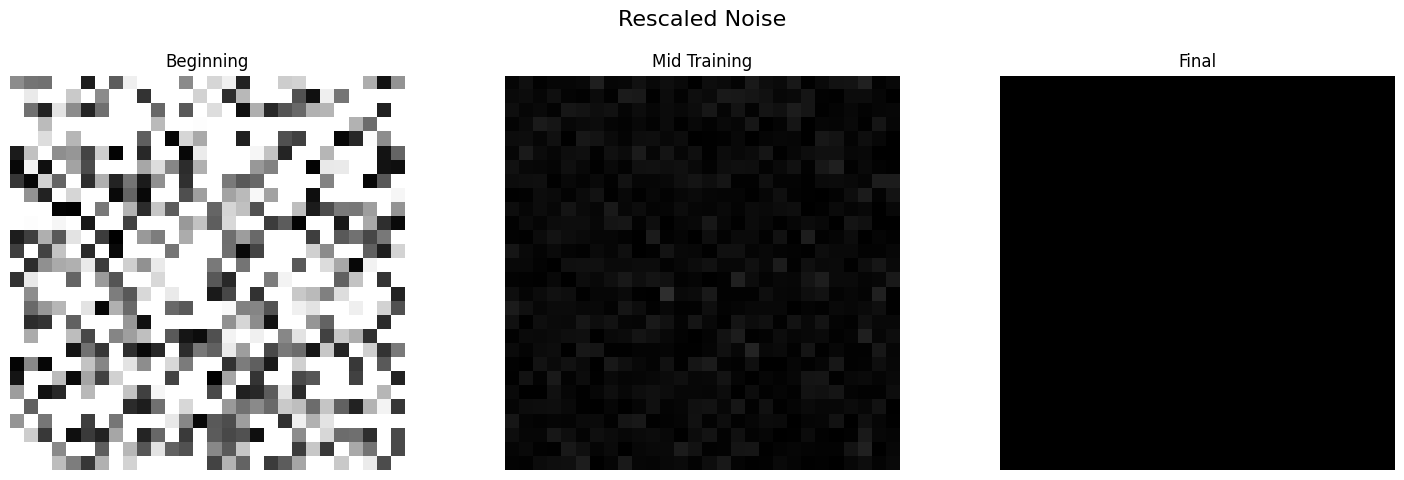

In [10]:
rescaled_noise = (
    torch.abs(noise_preds) * torch.sqrt(1 - noise_scales) / torch.sqrt(noise_scales)
)

plot_pictures(
    rescaled_noise,
    ["Beginning", "Mid Training", "Final"],
    super_title="Rescaled Noise",
    same_scale=True,
)

## Visualising the estimated images

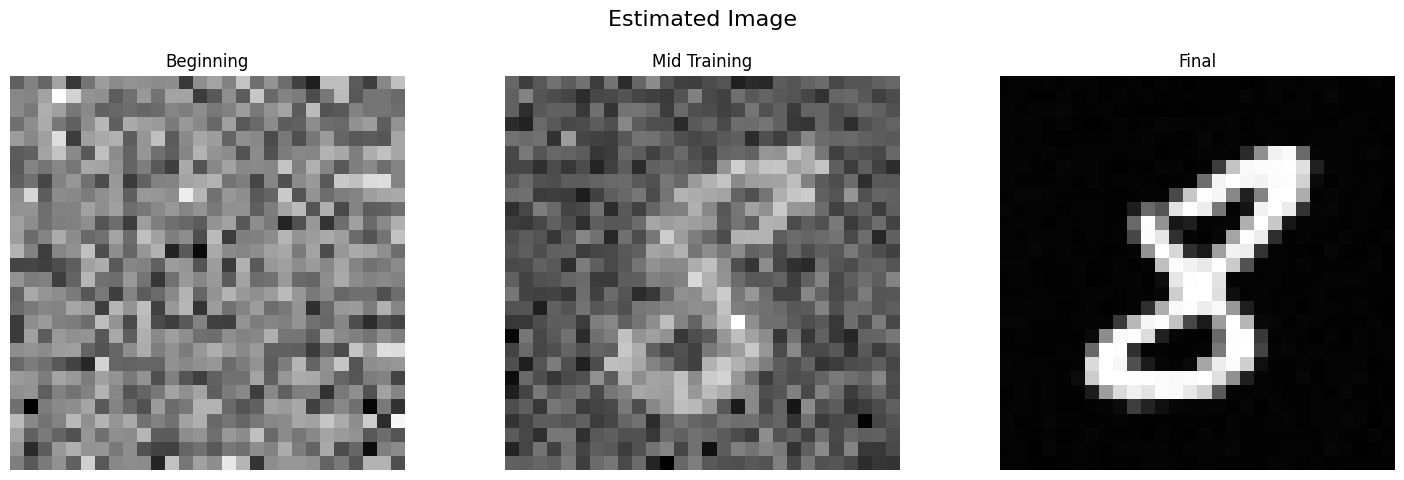

In [11]:
img_coeff = 1 / torch.sqrt(noise_scales)
noise_coeff = torch.sqrt(1 - noise_scales) / torch.sqrt(noise_scales)
images = img_coeff * intermediates - noise_coeff * noise_preds

plot_pictures(
    images,
    ["Beginning", "Mid Training", "Final"],
    super_title="Estimated Image",
    same_scale=False,
)